# 💵 Loan Prediction: Hypothesis Testing and Supervised Modeling

**Subject:** Machine Learning Internship Project  
**Project:** Loan Prediction  
**Dataset:** `loan_approval_dataset.csv` (Kaggle – Loan Approval Prediction Dataset)  
**Goal:** Use inferential statistics to validate assumptions, then build supervised models to predict whether a loan is **Approved** or **Rejected**.

---

## Notebook Roadmap
1. Setup and data loading  
2. Dataset exploration and EDA  
3. Missing values and duplicate checks  
4. Hypothesis testing (T-Test, Chi-Square, ANOVA concept)  
5. Data preprocessing and encoding  
6. Feature selection with `SelectKBest`  
7. Model training (Logistic Regression + Decision Tree)  
8. Evaluation (Accuracy, Confusion Matrix, ROC-AUC, Recall)  
9. Final model selection  
10. Save best model as `.pkl`


In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import ttest_ind, chi2_contingency

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import joblib

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


## 1. Load the Dataset

#### This dataset has extra spaces in column names and string values, so we will clean that immediately after loading.


In [4]:
df = pd.read_csv("loan_approval_dataset.csv")

print("Raw shape:", df.shape)
display(df.head())

# Remove extra spaces in column names
df.columns = df.columns.str.strip()

# Remove extra spaces from string columns
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.strip()

print("\nCleaned column names:")
print(df.columns.tolist())

print("\nShape after cleaning labels/spaces:", df.shape)
display(df.head())


Raw shape: (4269, 13)


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected



Cleaned column names:
['loan_id', 'no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'loan_status']

Shape after cleaning labels/spaces: (4269, 13)


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


## 2. Dataset Exploration

We will inspect:
- first and last rows  
- shape  
- data types  
- unique values  
- descriptive statistics


In [5]:
print("<--- First 5 rows --->")
display(df.head())

<--- First 5 rows --->


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [6]:
print("\n<--- Last 5 rows --->")
display(df.tail())


<--- Last 5 rows --->


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved
4268,4269,1,Graduate,No,9200000,29700000,10,607,17800000,11800000,35700000,12000000,Approved


In [7]:
print("\n<--- Shape --->")
print("Rows:", df.shape[0], "| Columns:", df.shape[1])


<--- Shape --->
Rows: 4269 | Columns: 13


In [8]:
print("\n<--- Data Types --->")
display(df.dtypes)


<--- Data Types --->


loan_id                      int64
no_of_dependents             int64
education                   object
self_employed               object
income_annum                 int64
loan_amount                  int64
loan_term                    int64
cibil_score                  int64
residential_assets_value     int64
commercial_assets_value      int64
luxury_assets_value          int64
bank_asset_value             int64
loan_status                 object
dtype: object

In [9]:
print("\n<--- Info --->")
df.info()


<--- Info --->
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [10]:
print("\n<--- Unique Value Count Per Column --->")
display(df.nunique().sort_values(ascending=False))


<--- Unique Value Count Per Column --->


loan_id                     4269
cibil_score                  601
luxury_assets_value          379
loan_amount                  378
residential_assets_value     278
commercial_assets_value      188
bank_asset_value             146
income_annum                  98
loan_term                     10
no_of_dependents               6
education                      2
self_employed                  2
loan_status                    2
dtype: int64

In [11]:
print("\n<--- Example Unique Values --->")
for col in df.columns:
    examples = df[col].drop_duplicates().head(10).tolist()
    print(f"{col}: {examples}")


<--- Example Unique Values --->
loan_id: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
no_of_dependents: [2, 0, 3, 5, 4, 1]
education: ['Graduate', 'Not Graduate']
self_employed: ['No', 'Yes']
income_annum: [9600000, 4100000, 9100000, 8200000, 9800000, 4800000, 8700000, 5700000, 800000, 1100000]
loan_amount: [29900000, 12200000, 29700000, 30700000, 24200000, 13500000, 33000000, 15000000, 2200000, 4300000]
loan_term: [12, 8, 20, 10, 4, 2, 18, 16, 14, 6]
cibil_score: [778, 417, 506, 467, 382, 319, 678, 782, 388, 547]
residential_assets_value: [2400000, 2700000, 7100000, 18200000, 12400000, 6800000, 22500000, 13200000, 1300000, 3200000]
commercial_assets_value: [17600000, 2200000, 4500000, 3300000, 8200000, 8300000, 14800000, 5700000, 800000, 1400000]
luxury_assets_value: [22700000, 8800000, 33300000, 23300000, 29400000, 13700000, 29200000, 11800000, 2800000, 3300000]
bank_asset_value: [8000000, 3300000, 12800000, 7900000, 5000000, 5100000, 4300000, 6000000, 600000, 1600000]
loan_status: ['Approved', 

In [12]:
print("\n<--- Numeric Summary --->")
display(df.describe().T)


<--- Numeric Summary --->


,count,mean,std,min,25%,50%,75%,max
loan_id,"4,269.0000","2,135.0000","1,232.4985",1.0000,"1,068.0000","2,135.0000","3,202.0000","4,269.0000"
no_of_dependents,"4,269.0000",2.4987,1.6959,0.0000,1.0000,3.0000,4.0000,5.0000
income_annum,"4,269.0000","5,059,123.9166","2,806,839.8318","200,000.0000","2,700,000.0000","5,100,000.0000","7,500,000.0000","9,900,000.0000"
loan_amount,"4,269.0000","15,133,450.4568","9,043,362.9848","300,000.0000","7,700,000.0000","14,500,000.0000","21,500,000.0000","39,500,000.0000"
loan_term,"4,269.0000",10.9004,5.7092,2.0000,6.0000,10.0000,16.0000,20.0000
cibil_score,"4,269.0000",599.9361,172.4304,300.0000,453.0000,600.0000,748.0000,900.0000
residential_assets_value,"4,269.0000","7,472,616.5378","6,503,636.5877","-100,000.0000","2,200,000.0000","5,600,000.0000","11,300,000.0000","29,100,000.0000"
commercial_assets_value,"4,269.0000","4,973,155.3057","4,388,966.0896",0.0000,"1,300,000.0000","3,700,000.0000","7,600,000.0000","19,400,000.0000"
luxury_assets_value,"4,269.0000","15,126,305.9264","9,103,753.6653","300,000.0000","7,500,000.0000","14,600,000.0000","21,700,000.0000","39,200,000.0000"
bank_asset_value,"4,269.0000","4,976,692.4338","3,250,185.3057",0.0000,"2,300,000.0000","4,600,000.0000","7,100,000.0000","14,700,000.0000"


## 3. Missing Value and Duplicate Analysis

This checks:
- missing values count and percentage  
- duplicate rows  
- optional missing value heatmap


In [13]:
missing_count = df.isnull().sum()
missing_percent = (missing_count / len(df)) * 100

missing_df = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percent": missing_percent.round(4)
}).sort_values(by="missing_count", ascending=False)

print("Missing Values Summary:")
display(missing_df)

duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

if missing_count.sum() == 0:
    print("✅ No missing values detected.")
else:
    plt.figure(figsize=(8, 4))
    sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
    plt.title("Missing Values Heatmap")
    plt.xlabel("Columns")
    plt.ylabel("Records")
    plt.show()


Missing Values Summary:


,missing_count,missing_percent
loan_id,0,0.0000
no_of_dependents,0,0.0000
education,0,0.0000
self_employed,0,0.0000
income_annum,0,0.0000
loan_amount,0,0.0000
loan_term,0,0.0000
cibil_score,0,0.0000
residential_assets_value,0,0.0000
commercial_assets_value,0,0.0000


Duplicate rows: 0
✅ No missing values detected.


## 4. Class Distribution and Quick EDA

We inspect:
- loan approval distribution  
- categorical distributions  
- correlation heatmap for numeric columns


Loan Status Distribution:


loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

loan_status
Approved   62.2200
Rejected   37.7800
Name: proportion, dtype: float64

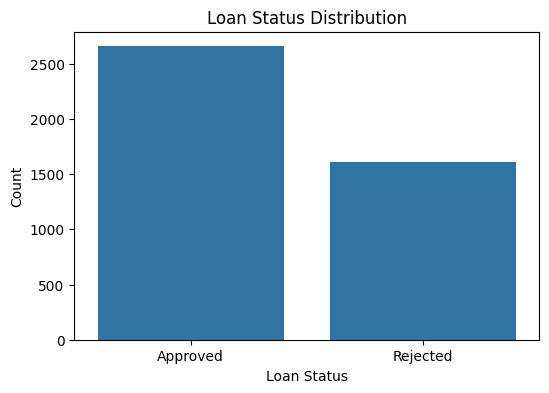


--- EDUCATION ---


education
Graduate        2144
Not Graduate    2125
Name: count, dtype: int64

education
Graduate       50.2200
Not Graduate   49.7800
Name: proportion, dtype: float64


--- SELF_EMPLOYED ---


self_employed
Yes    2150
No     2119
Name: count, dtype: int64

self_employed
Yes   50.3600
No    49.6400
Name: proportion, dtype: float64


--- LOAN_STATUS ---


loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

loan_status
Approved   62.2200
Rejected   37.7800
Name: proportion, dtype: float64

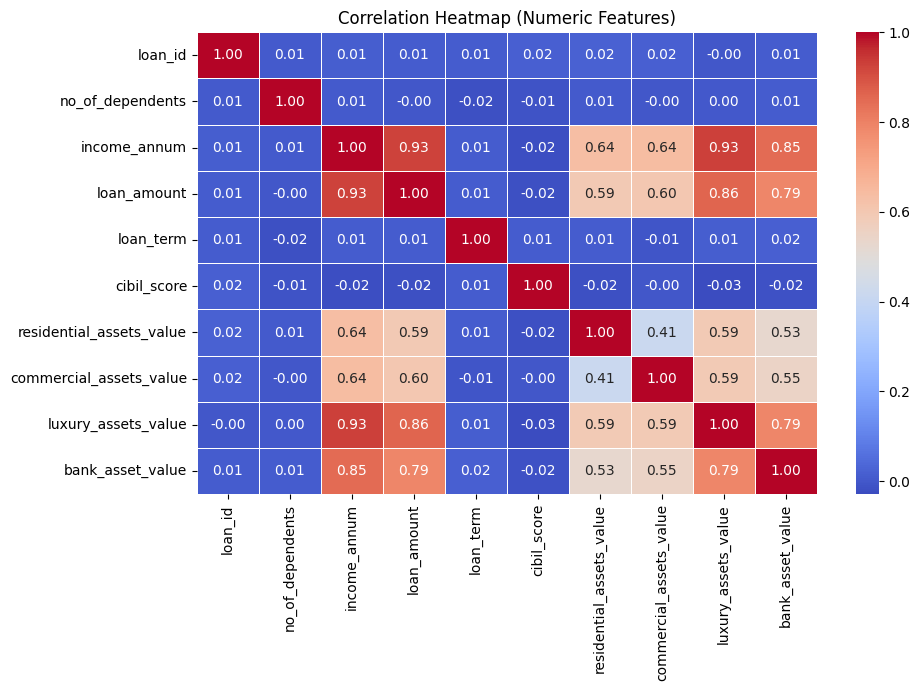

In [14]:
print("Loan Status Distribution:")
display(df["loan_status"].value_counts())
display((df["loan_status"].value_counts(normalize=True) * 100).round(2))

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="loan_status")
plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.show()

categorical_cols = ["education", "self_employed", "loan_status"]

for col in categorical_cols:
    print(f"\n--- {col.upper()} ---")
    display(df[col].value_counts())
    display((df[col].value_counts(normalize=True) * 100).round(2))

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(10, 6))
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()


## 5. Hypothesis Testing

We will perform:
1. **Two-sample T-Test**  
2. **Chi-Square Test of Independence**  
3. **ANOVA (conceptual explanation only)**

---

### A. T-Test
**Question:** Is the mean `income_annum` significantly different between approved and rejected loans?

- **Null Hypothesis (H₀):** Mean applicant income is the same for approved and rejected loans.  
- **Alternative Hypothesis (H₁):** Mean applicant income is different for approved and rejected loans.


In [15]:
approved_income = df.loc[df["loan_status"] == "Approved", "income_annum"]
rejected_income = df.loc[df["loan_status"] == "Rejected", "income_annum"]

t_stat, p_val_t = ttest_ind(approved_income, rejected_income, equal_var=False)

print("Mean income (Approved):", round(approved_income.mean(), 2))
print("Mean income (Rejected):", round(rejected_income.mean(), 2))
print("T-statistic:", round(t_stat, 4))
print("P-value:", p_val_t)

alpha = 0.05
if p_val_t < alpha:
    print("✅ Reject H0: Mean income differs significantly.")
else:
    print("❌ Fail to reject H0: No statistically significant difference in mean income.")


Mean income (Approved): 5025903.61
Mean income (Rejected): 5113825.17
T-statistic: -0.997
P-value: 0.31882633058964843
❌ Fail to reject H0: No statistically significant difference in mean income.


### B. Chi-Square Test
**Question:** Is there a significant relationship between `education` and `loan_status`?

- **Null Hypothesis (H₀):** `education` and `loan_status` are independent.  
- **Alternative Hypothesis (H₁):** `education` and `loan_status` are associated.


In [16]:
contingency_table = pd.crosstab(df["education"], df["loan_status"])
display(contingency_table)

chi2_stat, p_val_chi, dof, expected = chi2_contingency(contingency_table)

print("Chi-square statistic:", round(chi2_stat, 4))
print("Degrees of freedom:", dof)
print("P-value:", p_val_chi)

expected_df = pd.DataFrame(
    expected,
    index=contingency_table.index,
    columns=contingency_table.columns
)
print("\nExpected Frequencies:")
display(expected_df)

alpha = 0.05
if p_val_chi < alpha:
    print("✅ Reject H0: Education and loan status are significantly related.")
else:
    print("❌ Fail to reject H0: No statistically significant relationship detected.")


loan_status,Approved,Rejected
education,,
Graduate,1339,805
Not Graduate,1317,808


Chi-square statistic: 0.084
Degrees of freedom: 1
P-value: 0.7720042291016309

Expected Frequencies:


loan_status,Approved,Rejected
education,,
Graduate,"1,333.9105",810.0895
Not Graduate,"1,322.0895",802.9105


❌ Fail to reject H0: No statistically significant relationship detected.


### C. ANOVA (Conceptual)

**Why ANOVA?**  
If we divide applicants into **three or more groups** (for example: low income, medium income, high income) and want to compare the **mean loan amount** across those groups, a T-Test is no longer appropriate because a T-Test compares only **two groups**.

**ANOVA is appropriate because:**
- it compares means across **3+ groups**
- it controls Type-I error better than running many separate T-Tests
- it tells us whether **at least one group mean differs** from the others

**Example use case here:**  
Compare mean `loan_amount` across:
- Low income bracket
- Medium income bracket
- High income bracket

If ANOVA gives a significant p-value, then post-hoc tests (like Tukey’s test) can be used to identify which exact groups differ.


## 6. Data Preparation and Encoding

### Preprocessing decisions
- Drop `loan_id` because it is only an identifier.
- Use **Label Encoding style mapping** for binary columns:
  - `education`: Graduate / Not Graduate
  - `self_employed`: Yes / No
  - `loan_status`: Approved / Rejected
- There are no multi-class categorical predictor columns in this dataset, so **One-Hot Encoding is not required here**.
- We will still mention that **if multi-class categorical columns were present**, One-Hot Encoding would be the correct method.
- Class imbalance is mild, so we will:
  - use `stratify=y` in train/test split
  - use `class_weight='balanced'` in our classifiers  
  - mention **SMOTE** as an advanced balancing technique (conceptually)


In [17]:
df_model = df.drop(columns=["loan_id"]).copy()

categorical_mappings = {
    "education": {"Not Graduate": 0, "Graduate": 1},
    "self_employed": {"No": 0, "Yes": 1}
}
target_mapping = {"Rejected": 0, "Approved": 1}

for col, mapping in categorical_mappings.items():
    df_model[col] = df_model[col].map(mapping)

df_model["loan_status"] = df_model["loan_status"].map(target_mapping)

print("Encoded dataset preview:")
display(df_model.head())

print("\nEncoded data types:")
display(df_model.dtypes)

X = df_model.drop(columns=["loan_status"]).copy()
y = df_model["loan_status"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)


Encoded dataset preview:


,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1
1,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
3,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0
4,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0



Encoded data types:


no_of_dependents            int64
education                   int64
self_employed               int64
income_annum                int64
loan_amount                 int64
loan_term                   int64
cibil_score                 int64
residential_assets_value    int64
commercial_assets_value     int64
luxury_assets_value         int64
bank_asset_value            int64
loan_status                 int64
dtype: object

X shape: (4269, 11)
y shape: (4269,)


## 7. Feature Selection with `SelectKBest`

We will select the **top 10 features** using **Chi-Square (`chi2`)**.

> Important: `chi2` requires all features to be **non-negative**.  
> In this dataset, `residential_assets_value` contains a few negative values, so we will shift any negative-valued feature upward **only for feature selection**.

This lets us:
- follow the project requirement
- rank the best predictors
- reduce less useful input features before training


In [18]:
X_for_chi2 = X.copy()
chi2_shift_values = {}

for col in X_for_chi2.columns:
    min_val = X_for_chi2[col].min()
    if min_val < 0:
        shift_amount = abs(min_val) + 1
        X_for_chi2[col] = X_for_chi2[col] + shift_amount
        chi2_shift_values[col] = shift_amount
    else:
        chi2_shift_values[col] = 0

selector = SelectKBest(score_func=chi2, k=10)
selector.fit(X_for_chi2, y)

feature_scores = pd.DataFrame({
    "Feature": X.columns,
    "Chi2_Score": selector.scores_
}).sort_values(by="Chi2_Score", ascending=False)

selected_features = X.columns[selector.get_support()].tolist()

print("Selected Top 10 Features:")
print(selected_features)

print("\nFeature Scores:")
display(feature_scores)

# Create final selected feature matrix
X_selected = X[selected_features].copy()


Selected Top 10 Features:
['no_of_dependents', 'education', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']

Feature Scores:


,Feature,Chi2_Score
4,loan_amount,"6,015,537.4009"
9,luxury_assets_value,"5,592,630.8569"
7,residential_assets_value,"4,920,324.5729"
3,income_annum,"1,533,386.7192"
8,commercial_assets_value,"1,124,060.3415"
10,bank_asset_value,"416,254.8828"
6,cibil_score,"125,577.8707"
5,loan_term,163.0650
0,no_of_dependents,1.6120
1,education,0.0514


## 8. Train/Test Split

We use:
- **80% training**
- **20% testing**
- `stratify=y` to preserve the class distribution


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nTrain target distribution:")
display(y_train.value_counts(normalize=True).round(4))

print("\nTest target distribution:")
display(y_test.value_counts(normalize=True).round(4))


X_train: (3415, 10)
X_test : (854, 10)
y_train: (3415,)
y_test : (854,)

Train target distribution:


loan_status
1   0.6223
0   0.3777
Name: proportion, dtype: float64


Test target distribution:


loan_status
1   0.6218
0   0.3782
Name: proportion, dtype: float64

## 9. Model 1: Logistic Regression

Because Logistic Regression is distance-sensitive, we scale the input features first.


In [20]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

log_reg_model.fit(X_train_scaled, y_train)

print("✅ Logistic Regression trained successfully.")


✅ Logistic Regression trained successfully.


## 10. Model 2: Decision Tree Classifier

Decision Trees do not require feature scaling.


In [21]:
dt_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42
)

dt_model.fit(X_train, y_train)

print("✅ Decision Tree trained successfully.")


✅ Decision Tree trained successfully.


## 11. Model Evaluation

We will report for both models:
- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix
- ROC-AUC

> For loan approval problems, **Recall** can be especially important depending on the business objective.  
> If the goal is to correctly identify truly approvable applicants, higher recall for the **Approved** class is valuable.


In [22]:
def evaluate_model(model_name, y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)
    cm = confusion_matrix(y_true, y_pred)

    print(f"===== {model_name} =====")
    print("Accuracy :", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("Recall   :", round(rec, 4))
    print("F1-score :", round(f1, 4))
    print("ROC-AUC  :", round(roc_auc, 4))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc:.4f})")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.title(f"ROC Curve - {model_name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

    return {
        "Model": model_name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1_Score": f1,
        "ROC_AUC": roc_auc
    }


===== Logistic Regression =====
Accuracy : 0.9251
Precision: 0.9569
Recall   : 0.9209
F1-score : 0.9386
ROC-AUC  : 0.9734

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.93      0.90       323
           1       0.96      0.92      0.94       531

    accuracy                           0.93       854
   macro avg       0.92      0.93      0.92       854
weighted avg       0.93      0.93      0.93       854



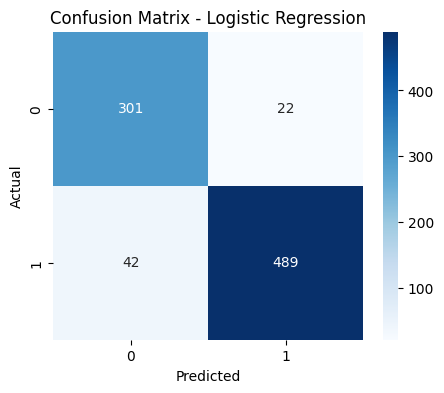

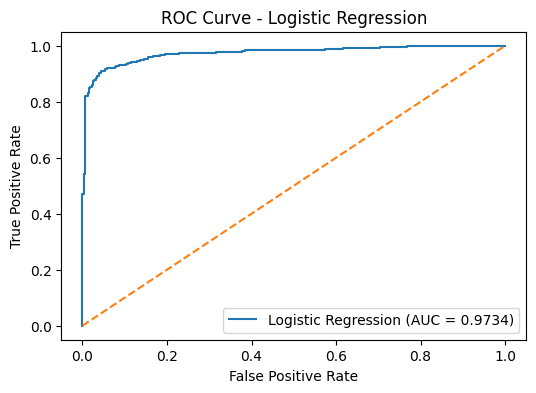

In [23]:
y_pred_lr = log_reg_model.predict(X_test_scaled)
y_prob_lr = log_reg_model.predict_proba(X_test_scaled)[:, 1]

log_reg_results = evaluate_model(
    model_name="Logistic Regression",
    y_true=y_test,
    y_pred=y_pred_lr,
    y_prob=y_prob_lr
)


===== Decision Tree =====
Accuracy : 0.9754
Precision: 0.9904
Recall   : 0.9699
F1-score : 0.98
ROC-AUC  : 0.9935

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       323
           1       0.99      0.97      0.98       531

    accuracy                           0.98       854
   macro avg       0.97      0.98      0.97       854
weighted avg       0.98      0.98      0.98       854



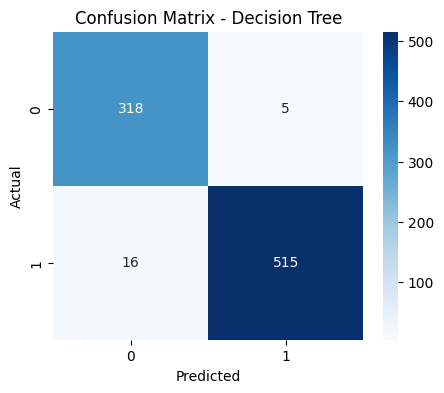

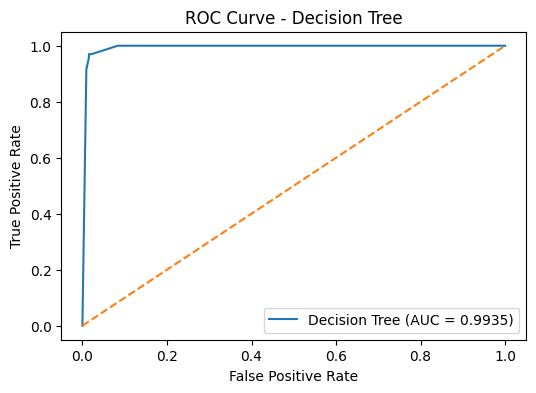

In [24]:
y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

dt_results = evaluate_model(
    model_name="Decision Tree",
    y_true=y_test,
    y_pred=y_pred_dt,
    y_prob=y_prob_dt
)


## 12. Model Comparison and Final Selection

We will compare the models using:
- Accuracy
- Recall
- ROC-AUC

### Selection logic
For this project, we prioritize:
1. **Recall**
2. **ROC-AUC**
3. **Accuracy**

This is a reasonable rule because in lending workflows, catching truly approvable cases can be very important (depending on the business definition of the positive class).


In [25]:
comparison_df = pd.DataFrame([log_reg_results, dt_results]).sort_values(
    by=["Recall", "ROC_AUC", "Accuracy"],
    ascending=False
).reset_index(drop=True)

display(comparison_df)

best_model_name = comparison_df.loc[0, "Model"]

if best_model_name == "Logistic Regression":
    best_model = log_reg_model
    best_scaler = scaler
else:
    best_model = dt_model
    best_scaler = None

print("Best Model Selected:", best_model_name)


,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Decision Tree,0.9754,0.9904,0.9699,0.9800,0.9935
1,Logistic Regression,0.9251,0.9569,0.9209,0.9386,0.9734


Best Model Selected: Decision Tree


## 13. Save the Final Model as `.pkl`

We will save a **bundle** that contains:
- best trained model
- selected feature list
- categorical mappings
- target mapping
- scaler (only if needed)

This makes deployment easier later.


In [26]:
model_bundle = {
    "model_name": best_model_name,
    "model": best_model,
    "selected_features": selected_features,
    "categorical_mappings": categorical_mappings,
    "target_mapping": target_mapping,
    "scaler": best_scaler,
    "chi2_shift_values": chi2_shift_values
}

joblib.dump(model_bundle, "loan_prediction_best_model.pkl")

print("✅ Saved successfully: loan_prediction_best_model.pkl")


✅ Saved successfully: loan_prediction_best_model.pkl


## 14. Reload the Saved `.pkl` File (Sanity Check)

This confirms that the saved model file can be loaded correctly.


In [27]:
loaded_bundle = joblib.load("loan_prediction_best_model.pkl")

print("Loaded model name:", loaded_bundle["model_name"])
print("Selected features:", loaded_bundle["selected_features"])
print("Scaler present:", loaded_bundle["scaler"] is not None)
print("Model type:", type(loaded_bundle["model"]))


Loaded model name: Decision Tree
Selected features: ['no_of_dependents', 'education', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']
Scaler present: False
Model type: <class 'sklearn.tree._classes.DecisionTreeClassifier'>


## 15. Final Report 


#### A. Statistical Test Results
- T-Test hypotheses, statistic, p-value, and conclusion
- Chi-Square hypotheses, statistic, p-value, and conclusion
- ANOVA explanation (conceptual only)

#### B. Data Preparation
- Space trimming in columns and string values
- Dropping `loan_id`
- Binary encoding for `education` and `self_employed`
- Handling mild class imbalance conceptually using:
  - stratified split
  - class weights
  - mention of SMOTE for future work

#### C. Feature Selection
- Explain that `SelectKBest(chi2, k=10)` was used
- Mention that one feature had negative values, so a shift was applied only for chi-square scoring

#### D. Model Training
- Logistic Regression
- Decision Tree Classifier

#### E. Evaluation
- Accuracy
- Confusion Matrix
- ROC-AUC
- Recall (important metric for final model choice)

#### F. Final Conclusion
State which model performed best and justify the final choice using the comparison table.


--------------------------------------------------------------------

## 16. Advanced Tasks ( Beyond Internship Requirements )

#### The following analyses are not required by the internship documentation, but are added to strengthen model robustness, interpretability, and real-world deployment readiness.

### 16.1 Effect Size for T-Test (Cohen's d)

While p-values tell us whether a difference is statistically significant,
they do not tell us how large the difference actually is.

Cohen’s d measures the magnitude of difference in applicant income
between Approved and Rejected loans.

In [28]:
# Cohen's d calculation
mean_diff = approved_income.mean() - rejected_income.mean()

pooled_std = np.sqrt(
    ((approved_income.std() ** 2) + (rejected_income.std() ** 2)) / 2
)

cohens_d = mean_diff / pooled_std

print("Cohen's d:", round(cohens_d, 4))

if abs(cohens_d) < 0.2:
    interpretation = "Small effect"
elif abs(cohens_d) < 0.5:
    interpretation = "Medium effect"
else:
    interpretation = "Large effect"

print("Effect Size Interpretation:", interpretation)

Cohen's d: -0.0314
Effect Size Interpretation: Small effect


### 16.2 K-Fold Cross-Validation ( K = 5 )

To ensure model stability and reduce dependency on a single train-test split,
we perform 5-fold cross-validation using ROC-AUC as the scoring metric.

In [29]:
from sklearn.model_selection import cross_val_score

# Logistic Regression CV
cv_scores_lr = cross_val_score(
    log_reg_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="roc_auc"
)

print("Logistic Regression CV ROC-AUC Scores:", cv_scores_lr)
print("Mean CV ROC-AUC:", round(cv_scores_lr.mean(), 4))


# Decision Tree CV
cv_scores_dt = cross_val_score(
    dt_model,
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc"
)

print("\nDecision Tree CV ROC-AUC Scores:", cv_scores_dt)
print("Mean CV ROC-AUC:", round(cv_scores_dt.mean(), 4))

Logistic Regression CV ROC-AUC Scores: [0.96790698 0.97790242 0.96178751 0.96493388 0.96113999]
Mean CV ROC-AUC: 0.9667

Decision Tree CV ROC-AUC Scores: [0.99483356 0.99589603 0.9897264  0.99446876 0.98994072]
Mean CV ROC-AUC: 0.993


### 16.3 Feature Importance ( Decision Tree )

Decision Trees allow interpretability by showing which features
most influence loan approval decisions.

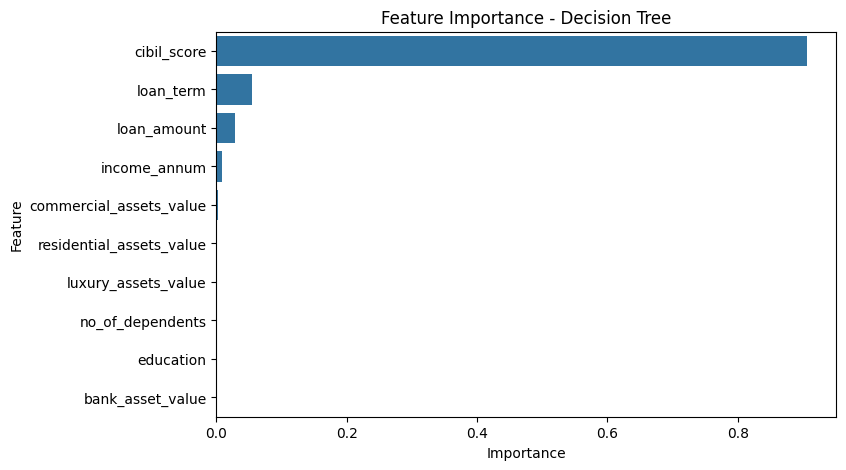

,Feature,Importance
5,cibil_score,0.9061
4,loan_term,0.0544
3,loan_amount,0.0283
2,income_annum,0.0079
7,commercial_assets_value,0.0018
6,residential_assets_value,0.0009
8,luxury_assets_value,0.0006
0,no_of_dependents,0.0000
1,education,0.0000
9,bank_asset_value,0.0000


In [30]:
importances = dt_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=feature_importance_df,
    x="Importance",
    y="Feature"
)
plt.title("Feature Importance - Decision Tree")
plt.show()

display(feature_importance_df)

### 16.4 Probability Threshold Analysis

By default, classification models use a 0.5 probability threshold.

However, in real banking systems, the threshold can be adjusted
to optimize Recall or Precision depending on business goals.

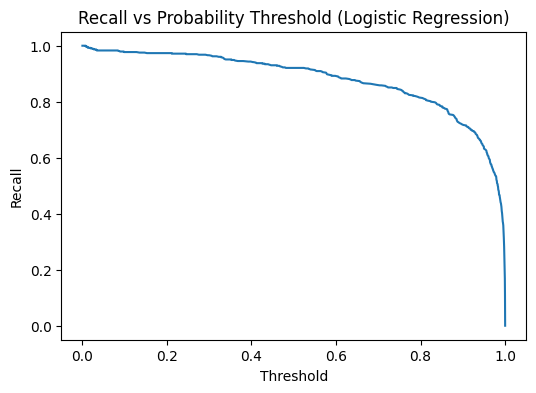

In [31]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob_lr)

plt.figure(figsize=(6, 4))
plt.plot(thresholds, recall[:-1])
plt.title("Recall vs Probability Threshold (Logistic Regression)")
plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.show()

### 16.5 Overfitting Check

We compare training and testing accuracy
to detect potential overfitting.

In [32]:
# Logistic Regression
train_acc_lr = accuracy_score(y_train, log_reg_model.predict(X_train_scaled))
test_acc_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Train Accuracy:", round(train_acc_lr, 4))
print("Logistic Regression Test Accuracy :", round(test_acc_lr, 4))


# Decision Tree
train_acc_dt = accuracy_score(y_train, dt_model.predict(X_train))
test_acc_dt = accuracy_score(y_test, y_pred_dt)

print("\nDecision Tree Train Accuracy:", round(train_acc_dt, 4))
print("Decision Tree Test Accuracy :", round(test_acc_dt, 4))

Logistic Regression Train Accuracy: 0.9192
Logistic Regression Test Accuracy : 0.9251

Decision Tree Train Accuracy: 0.9707
Decision Tree Test Accuracy : 0.9754
